In [2]:
import os
import sys
sys.path.append('../')
from data.utils import get_path, get_spikes, pca, sample_denoising
from matplotlib import pyplot as plt
from sklearn import preprocessing

import numpy as np

def path_exists(path):
    return os.path.exists(path) or os.path.islink(path)
    
def makedirs(dirpath):
    if path_exists(dirpath):
        return
    os.makedirs(dirpath)

In [3]:
save_dir_root_ = get_path()

In [4]:
# generate path to save data file at
def dict_to_str(my_dict):
    s = ''
    s += my_dict['rat_name'] + '_'
    s += my_dict['mod_name'] + '_'
    s += my_dict['sess_name'] + '_'
    s += my_dict['day_name'] + '_'
    if my_dict['rat_location'] is not None:
        if my_dict['negate_rat_location']:
            s += 'not_'
        for i in range(len(my_dict['rat_location']['coords'])):
            s += 'rat_loc_coords=(' + str(my_dict['rat_location']['coords'][i][0]) +\
                    ',' + str(my_dict['rat_location']['coords'][i][1]) + ')_'
            s += 'radius=' + str(my_dict['rat_location']['radius'][i]) + '_'
    if my_dict['bType'] is not None:
        s += str(my_dict['bType']) + '_'
    if not my_dict['bSmooth']:
        s += 'bSmooth='+str(my_dict['bSmooth']) + '_'
    if my_dict['smoothing_width'] > -1:
        s += 'SW=' + str(my_dict['smoothing_width']) + '_'
    s += 'subsample=' + my_dict['subsample_type'] + '_' + str(my_dict['num_times']) + '_'
    if my_dict['truncate_type'] is not None:
        if 'clip' in my_dict['truncate_type']:
            s += 'clip=' + str(my_dict['clip_interval'][0]) + '_' + str(my_dict['clip_interval'][1]) + '_'
        if 'active' in my_dict['truncate_type']:
            if type(my_dict['active_times']) == tuple:
                s += 'active=' + str(my_dict['active_times'][0]) + '_' + str(my_dict['active_times'][1]) + '_'
            else:
                s += 'active=' + str(my_dict['active_times']) + '_'
    if my_dict['standardize'] is not None:
        s += 'standardize=' + my_dict['standardize'] + '_'
    if my_dict['pc_source'] is not None:
        if my_dict['pc_source']=='compute':
            s += 'pc_dim=' + str(my_dict['dim']) + '_'
        else:
            s += 'pc_source=[['+my_dict['pc_source'].split('/')[-2] + ']]_'
    if my_dict['to_denoise']:
        s += 'k=' + str(my_dict['k']) + '_n_points=' + str(my_dict['n_points']) + '_'
        s += my_dict['metric'] + '_'
    return s[:-1]

In [5]:
# configure parameters to generate data
config = {
    'rat_name': 'R', ##
    'mod_name': '2', ## module
    'sess_name': 'OF', ## session
    'day_name': 'day1', ##
    'bType': 'pure', # pure/None to use "pure" grid cells or all the cells
    'bSmooth': True,
    'smoothing_width': 1500, ##
    'subsample_type': 'interval', # uniform/interval ##
    'num_times': 5, # if subsample_type==interval then subsample every num_times-th vector, if subsample_type==uniform, the subsample 1/num_times of the original data size ##
    'standardize': 'after', # None/after/before for no standardization or standardize before or after subsampling ##
    'pc_source': 'compute', # None/compute/path_to_saved_file_containing_pc_components ##
    'dim': 6, # pca dimension or path to data file containing already fitted pca ##
    'truncate_type': 'active', # active/clip/None ##
    'active_times': 15000, # if truncate_type==active, pick top population activity vectors or if tuple then (s,e), ex (-50000,-1000) ##
    'to_denoise': True, ## 
    'metric': 'cosine', ##
    'k': 1500, # log_2k ##
    'n_points': 4800, # topologically denoised subsample size ##
    # experimental parameters (switched off by default)
    'clip_interval': (0.9,1), # if truncate_type==clip, pick vectors in (int(start_fraction*n), int(end_fraction*n))
    'negate_rat_location': False,
    'rat_location': None, # {'coords': [], 'radius': []}, # {'coords': [(x,y),...], 'radius': [r,...]} or None
}

In [7]:
save_dir_root = os.path.join(save_dir_root_,dict_to_str(config))
makedirs(save_dir_root)

sspikes.shape (766731, 149)
Interval based subsampling leads to 153347 subsamples.


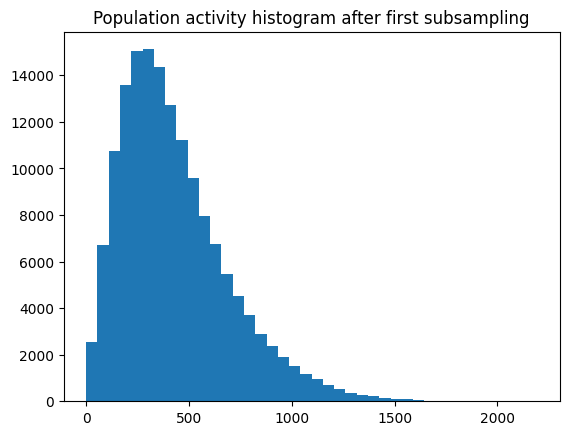

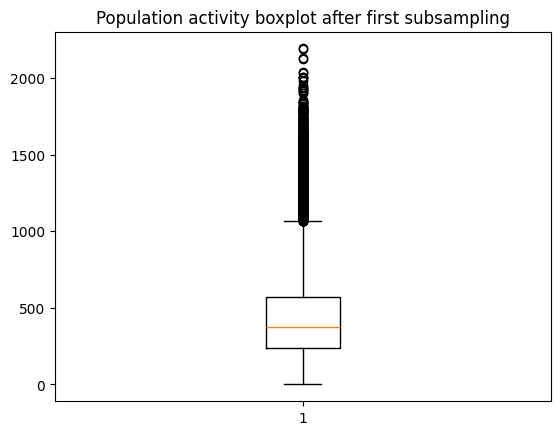

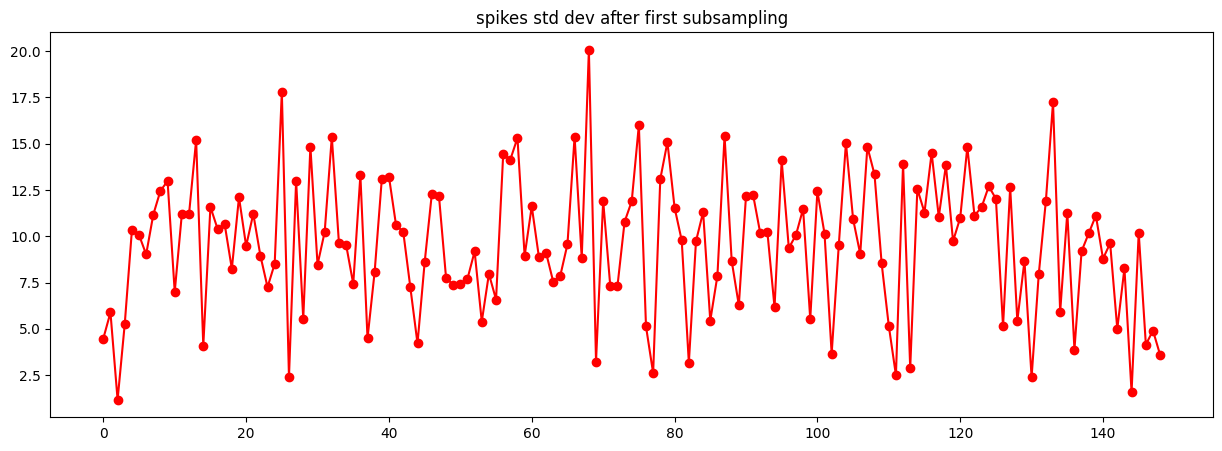

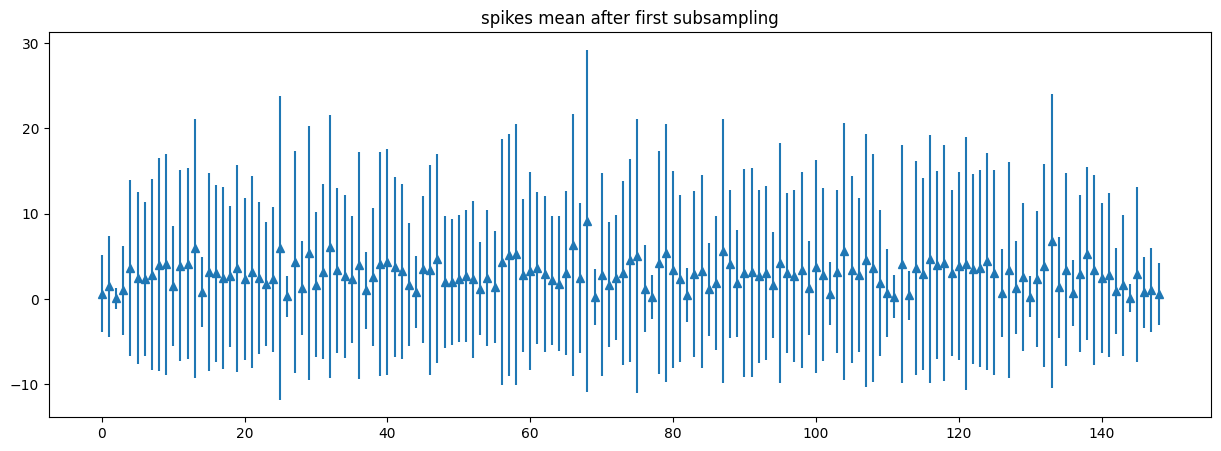

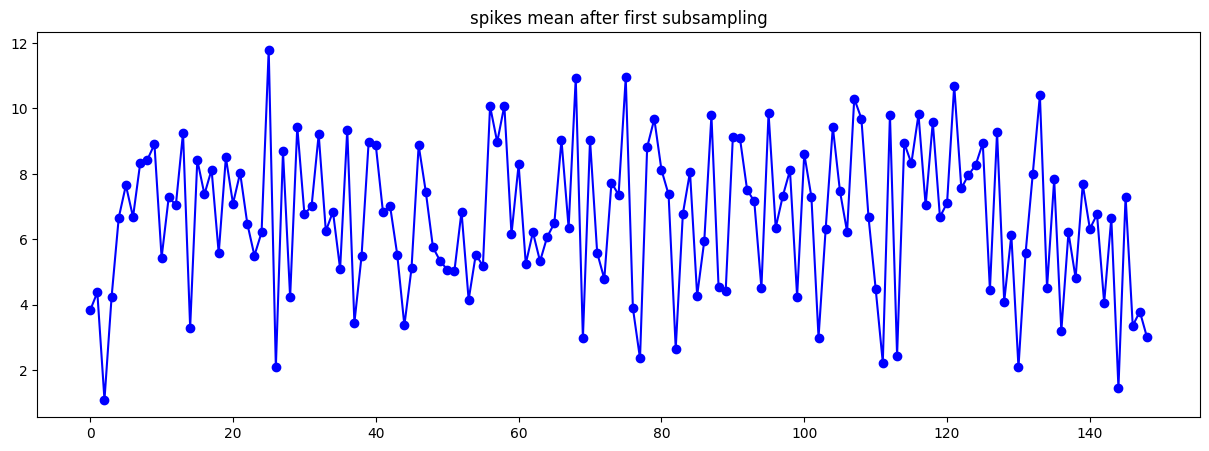

In [8]:
rat_name, mod_name, sess_name, day_name = (config['rat_name'], config['mod_name'], 
                                           config['sess_name'], config['day_name'])


# Get smoothed spike data (times when rat speed < 2.5cm/s removed)
sspikes,xx,yy,aa,tt = get_spikes(rat_name, mod_name, day_name, sess_name, 
                                 bSmooth = config['bSmooth'], bSpeed = True, bType=config['bType'],
                                 smoothing_width=config['smoothing_width'])

if config['rat_location'] is not None:
    mask = None
    for i in range(len(config['rat_location']['coords'])):
        coords = config['rat_location']['coords'][i]
        radius = config['rat_location']['radius'][i]
        mask_ = np.sqrt((xx-coords[0])**2 + (yy-coords[1])**2) < radius
        if mask is None:
            mask = mask_
        else:
            mask |= mask_
    
    if config['negate_rat_location']:
        mask = ~mask
    
    sspikes = sspikes[mask,:]
    xx = xx[mask]
    yy = yy[mask]
    tt = tt[mask]
    aa = aa[mask]

tt0 = tt.copy()
xx0 = xx.copy()
yy0 = yy.copy()
print('sspikes.shape', sspikes.shape)
num_neurons = len(sspikes[0,:])

# Subsample data
if config['subsample_type'] == 'interval':
    times_cube = np.arange(0,len(sspikes[:,0]),config['num_times'])
else:
    n_times = int(len(sspikes[:,0])/config['num_times'])
    times_cube = np.arange(len(sspikes[:,0]))
    np.random.seed(42)
    np.random.shuffle(times_cube)
    times_cube = times_cube[:n_times]
    
print('Interval based subsampling leads to', len(times_cube), 'subsamples.')


(_, bins, _) = plt.hist(np.sum(sspikes[times_cube,:],1), bins=40)
plt.title('Population activity histogram after first subsampling')
plt.savefig(save_dir_root+'/activity_hist_after_first_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.boxplot(np.sum(sspikes[times_cube,:],1))
plt.title('Population activity boxplot after first subsampling')
plt.savefig(save_dir_root+'/activity_bplot_after_first_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.plot(np.std(sspikes[times_cube,:], axis=0), 'ro-')
plt.title('spikes std dev after first subsampling')
plt.savefig(save_dir_root+'/activity_stddev_after_first_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.errorbar(np.arange(sspikes.shape[1]), np.mean(sspikes[times_cube,:], axis=0),
             np.std(sspikes[times_cube,:], axis=0), linestyle='None', marker='^')
plt.title('spikes mean after first subsampling')
plt.savefig(save_dir_root+'/activity_mean_after_first_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.plot(np.std(sspikes[times_cube,:], axis=0)-np.mean(sspikes[times_cube,:], axis=0), 'bo-')
plt.title('spikes mean after first subsampling')
plt.savefig(save_dir_root+'/activity_stddev_minus_mean_after_first_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

movetimes.shape (15000,)


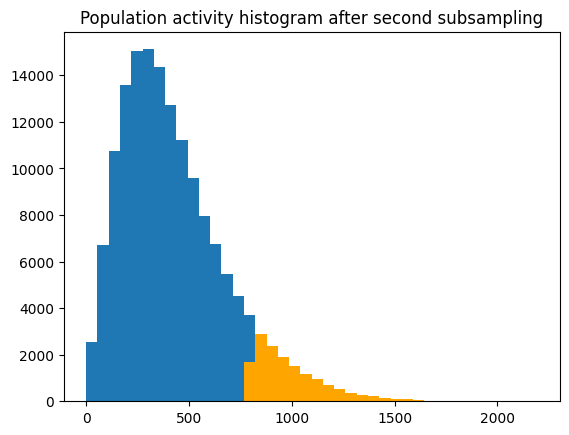

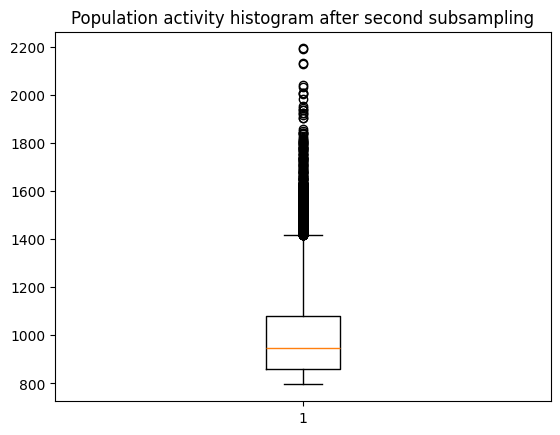

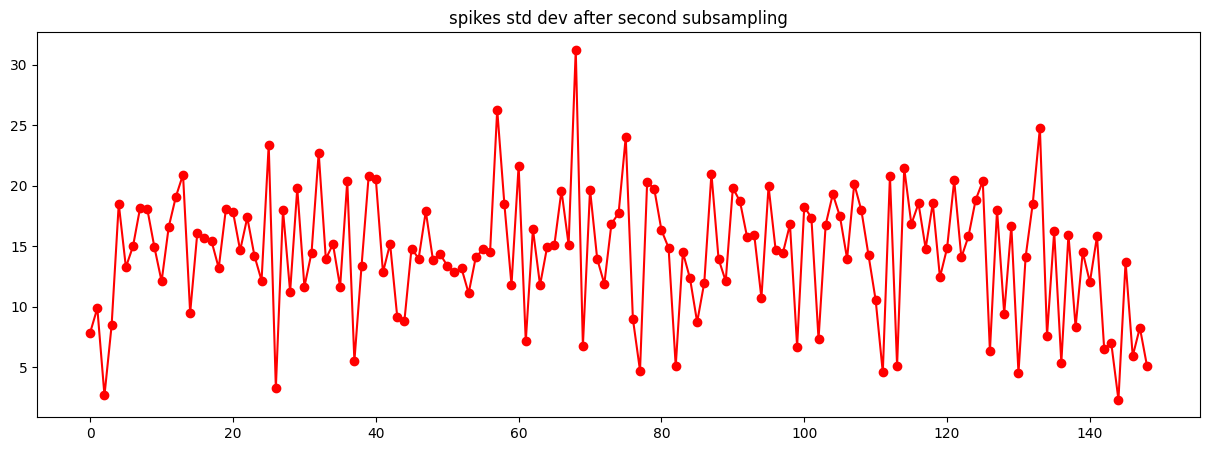

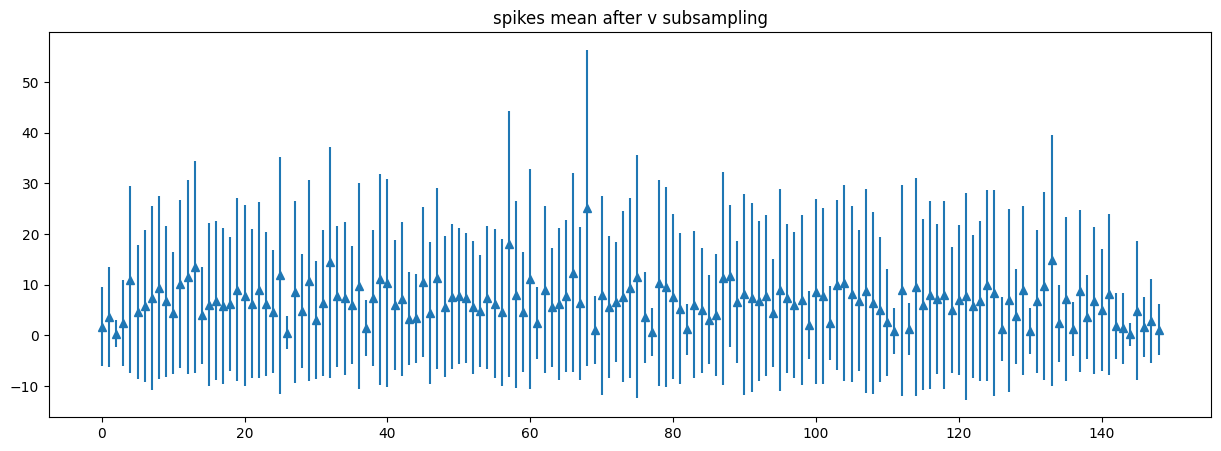

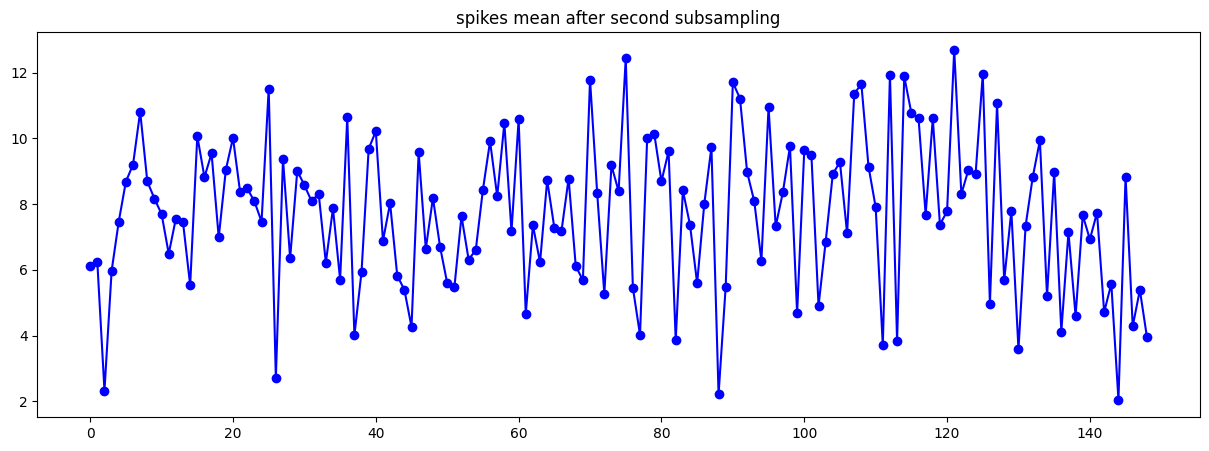

In [9]:
# Truncate data
movetimes = times_cube.copy()
if config['truncate_type'] is not None:
    if 'clip' in config['truncate_type']:
        s_, e_ = config['clip_interval']
        n_ = len(times_cube)
        s_ = int(s_*n_)
        e_ = int(e_*n_)
        movetimes = movetimes[s_:e_]
    if 'active' in config['truncate_type']:
        if type(config['active_times'])==tuple:
            s_, e_ = config['active_times']
            movetimes_ = np.sort(np.argsort(np.sum(sspikes[movetimes,:],1))[s_:e_])
        else:
            movetimes_ = np.sort(np.argsort(np.sum(sspikes[movetimes,:],1))[-config['active_times']:])
        movetimes = movetimes[movetimes_]

print('movetimes.shape', movetimes.shape)

plt.hist(np.sum(sspikes[times_cube,:],1), bins=bins)
plt.hist(np.sum(sspikes[movetimes,:],1), bins=bins, color='orange')
plt.title('Population activity histogram after second subsampling')
plt.savefig(save_dir_root+'/activity_hist_after_second_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.boxplot(np.sum(sspikes[movetimes,:],1))
plt.title('Population activity histogram after second subsampling')
plt.savefig(save_dir_root+'/activity_bplot_after_second_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.plot(np.std(sspikes[movetimes,:], axis=0), 'ro-')
plt.title('spikes std dev after second subsampling')
plt.savefig(save_dir_root+'/activity_stddev_after_second_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.errorbar(np.arange(sspikes.shape[1]), np.mean(sspikes[movetimes,:], axis=0),
             np.std(sspikes[movetimes,:], axis=0), linestyle='None', marker='^')
plt.title('spikes mean after v subsampling')
plt.savefig(save_dir_root+'/activity_mean_after_second_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(15,5))
plt.plot(np.std(sspikes[movetimes,:], axis=0)-np.mean(sspikes[movetimes,:], axis=0), 'bo-')
plt.title('spikes mean after second subsampling')
plt.savefig(save_dir_root+'/activity_stddev_minus_mean_after_second_subsample.png', bbox_inches='tight', dpi=300)
plt.show()

0.9999999999999905
4.203639730047021e-14
after subsampling and pca, dim_red_spikes_move_scaled.shape: (15000, 6)
(15000, 6)
15000
4800
after denoising, dim_red_spikes_move_scaled.shape: (4800, 6)


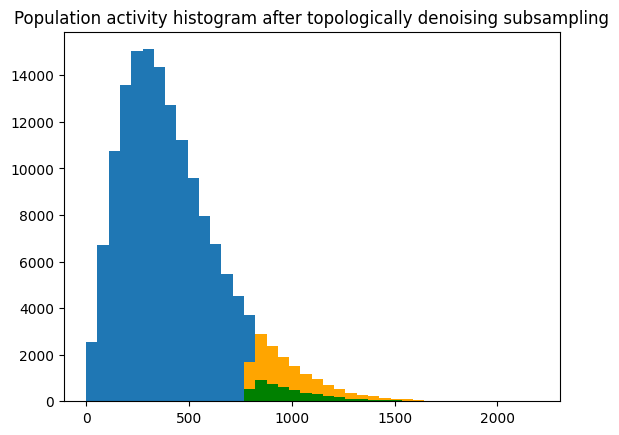

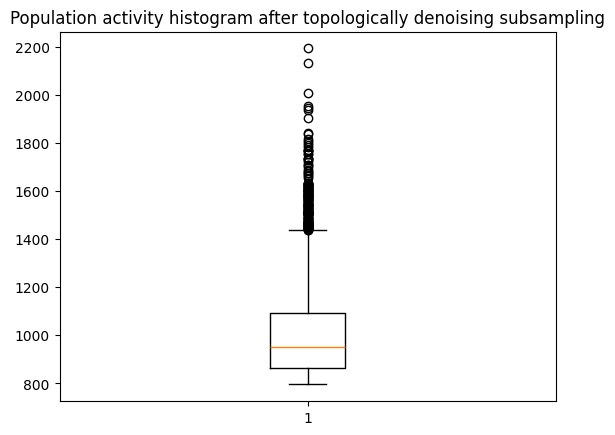

In [10]:
if config['standardize'] is not None:
    if config['standardize'] == 'before':
        standardized_spikes = preprocessing.scale(sspikes)[movetimes,:]
    elif config['standardize'] == 'after':
        standardized_spikes = preprocessing.scale(sspikes[movetimes,:])
else:
    standardized_spikes = sspikes[movetimes,:]

if config['pc_source'] is not None:
    standardized_spikes = preprocessing.scale(standardized_spikes, with_std=False)
    print(np.mean(np.std(standardized_spikes, axis=0)), flush=True)
    print(np.linalg.norm(np.mean(standardized_spikes, axis=0)), flush=True)
    if config['pc_source'] == 'compute':
        dim_red_spikes_move_scaled, __, __, evecs = pca(standardized_spikes, dim = config['dim'])
    else:
        _,_,_,_,_, evecs = np.load(config['pc_source'], allow_pickle=True)
        dim_red_spikes_move_scaled = np.dot(evecs.T, standardized_spikes.T).T 
    print('after subsampling and pca, dim_red_spikes_move_scaled.shape:', dim_red_spikes_move_scaled.shape)
else:
    evecs = None
    dim_red_spikes_move_scaled = sspikes[movetimes,:]
    print(np.mean(np.std(dim_red_spikes_move_scaled, axis=0)), flush=True)
    print(np.linalg.norm(np.mean(dim_red_spikes_move_scaled, axis=0)), flush=True)
    print('after subsampling, dim_red_spikes_move_scaled.shape:', dim_red_spikes_move_scaled.shape)

print(dim_red_spikes_move_scaled.shape)
print(len(movetimes))
xx = xx[movetimes]
yy = yy[movetimes]
aa = aa[movetimes]
tt = tt[movetimes]

if config['to_denoise']:
    indstemp,dd,fs  = sample_denoising(dim_red_spikes_move_scaled,  config['k'], 
                                        config['n_points'], 1, config['metric'])
    print(len(indstemp))
    dim_red_spikes_move_scaled = dim_red_spikes_move_scaled[indstemp,:]
    xx = xx[indstemp]
    yy = yy[indstemp]
    aa = aa[indstemp]
    tt = tt[indstemp]
    print('after denoising, dim_red_spikes_move_scaled.shape:', dim_red_spikes_move_scaled.shape)
    
    plt.hist(np.sum(sspikes[times_cube,:],1), bins=bins)
    plt.hist(np.sum(sspikes[movetimes,:],1), bins=bins, color='orange')
    plt.hist(np.sum(sspikes[movetimes[indstemp],:],1), bins=bins, color='green')
    plt.title('Population activity histogram after topologically denoising subsampling')
    plt.savefig(save_dir_root+'/activity_hist_after_topo_denoise.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    plt.boxplot(np.sum(sspikes[movetimes[indstemp],:],1))
    plt.title('Population activity histogram after topologically denoising subsampling')
    plt.savefig(save_dir_root+'/activity_bplot_after_topo_denoise.png', bbox_inches='tight', dpi=300)
    plt.show()

In [11]:
standardized_spikes = standardized_spikes[indstemp]

In [12]:
ind = np.argsort(tt)
xx = xx[ind]
yy = yy[ind]
aa = aa[ind]
tt = tt[ind]
dim_red_spikes_move_scaled = dim_red_spikes_move_scaled[ind,:]
standardized_spikes = standardized_spikes[ind]

(np.float64(-0.7990475237369538),
 np.float64(0.8094087183475495),
 np.float64(-0.7991314172744751),
 np.float64(0.8005712270736695))

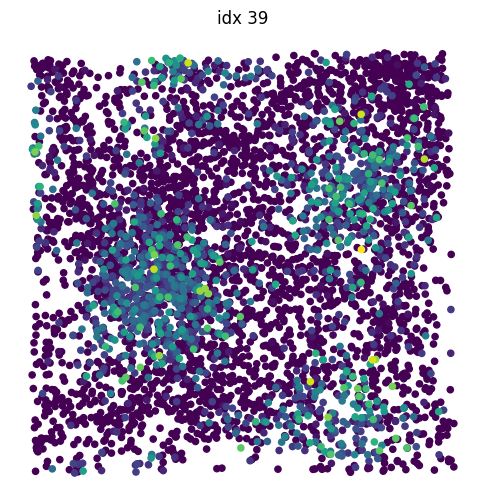

In [13]:
fig,  ax = plt.subplots(1,1, figsize=(6,6))
idx = 39  # 5 39 75 109 115
color = standardized_spikes[:, idx]
order = np.argsort(color)
ax.scatter(xx[order], yy[order], c=color[order], s=20)
ax.set_title(f"idx {idx}")
ax.axis("off")

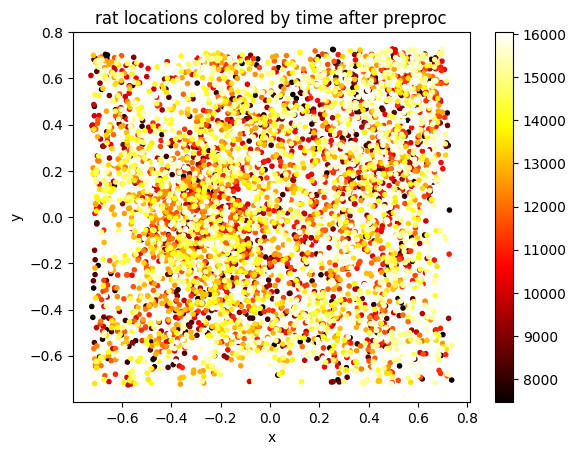

In [14]:
%matplotlib inline
plt.scatter(xx, yy, marker='.', c=tt, cmap='hot')
plt.xlabel('x')
plt.ylabel('y')
plt.title('rat locations colored by time after preproc')
plt.colorbar()
plt.savefig(save_dir_root+'/rat_locations_colored_by_time_after_preproc.png', bbox_inches='tight', dpi=300)

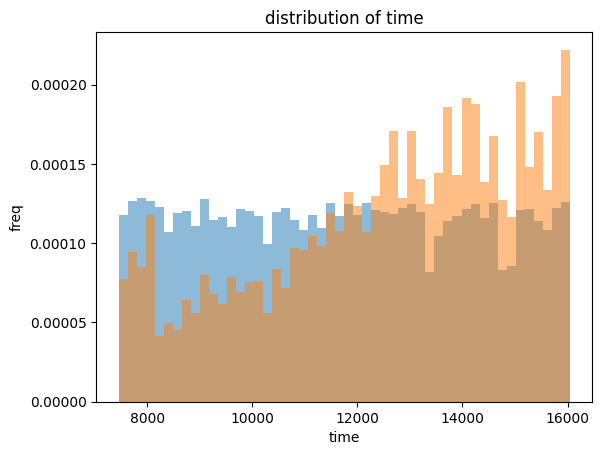

In [15]:
(_, bins_tt, _) = plt.hist(tt0, bins=50, density=True, alpha=0.5)
plt.hist(tt, bins=bins_tt, density=True, alpha=0.5)
plt.xlabel('time')
plt.ylabel('freq')
plt.title('distribution of time')
plt.savefig(save_dir_root+'/distribution_of_time_before_and_after_preprocessing.png', bbox_inches='tight', dpi=300)
plt.show()

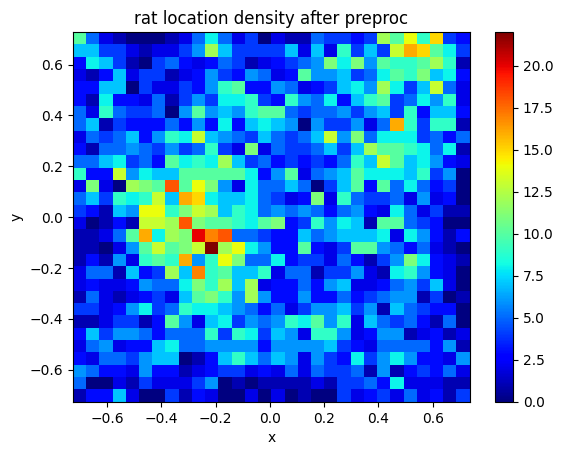

In [17]:
plt.hist2d(xx, yy, bins=(30,30), cmap=plt.cm.jet)
plt.xlabel('x')
plt.ylabel('y')
plt.title('rat location density after preproc')
plt.colorbar()
plt.savefig(save_dir_root+'/rat_location_density_after_preproc.png', bbox_inches='tight', dpi=300)

In [18]:
np.savez(save_dir_root+"/grid_cells_4800.npz",
         data=dim_red_spikes_move_scaled,
         xx=xx,
         yy=yy,
         aa=aa,
         tt=tt,
         evecs=evecs,
         spikes=standardized_spikes,)